# Project Goal


The goal of this project is to analyze historical stock market data, identify trends and seasonal patterns, and build predictive models to forecast future stock prices.

In [1]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [3]:
df = pd.read_csv("portfolio_data.csv")
df.head()

,Date,AMZN,DPZ,BTC,NFLX
0,5/1/2013,248.229996,51.190983,106.250000,30.415714
1,5/2/2013,252.550003,51.987320,98.099998,30.641428
2,5/3/2013,258.049988,52.446388,112.900002,30.492857
3,5/6/2013,255.720001,53.205257,109.599998,30.098572
4,5/7/2013,257.730011,54.151505,113.199997,29.464285


In [4]:
df.shape

(1520, 5)

In [5]:
df.isna().sum()

Date    0
AMZN    0
DPZ     0
BTC     0
NFLX    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1520 non-null   object 
 1   AMZN    1520 non-null   float64
 2   DPZ     1520 non-null   float64
 3   BTC     1520 non-null   float64
 4   NFLX    1520 non-null   float64
dtypes: float64(4), object(1)
memory usage: 59.5+ KB


In [8]:
df["Date"] = pd.to_datetime(df["Date"])

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1520 non-null   datetime64[ns]
 1   AMZN    1520 non-null   float64       
 2   DPZ     1520 non-null   float64       
 3   BTC     1520 non-null   float64       
 4   NFLX    1520 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 59.5 KB


# Stock Trend Analysis

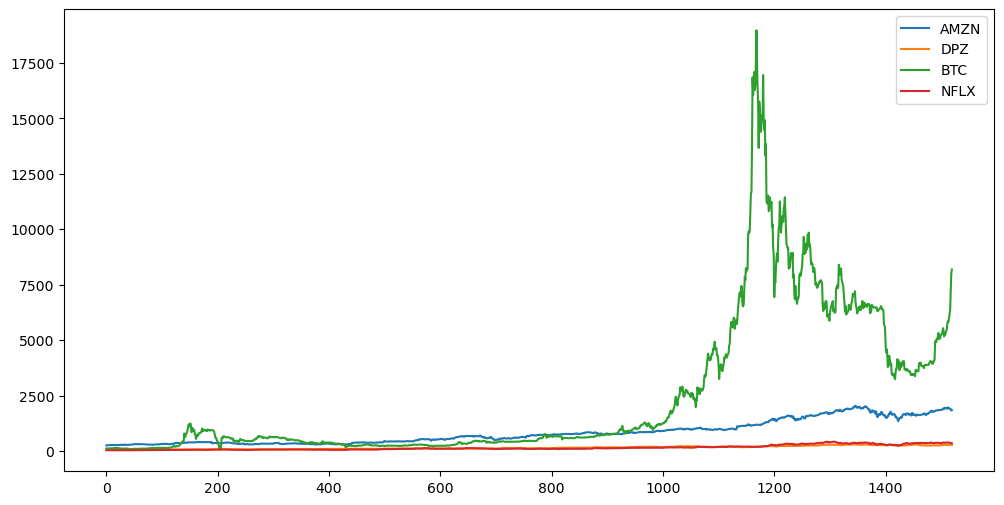

In [10]:
plt.figure(figsize=(12,6))

plt.plot(df['AMZN'], label='AMZN')
plt.plot(df['DPZ'], label='DPZ')
plt.plot(df['BTC'], label='BTC')
plt.plot(df['NFLX'], label='NFLX')

plt.legend()

plt.show()

# Moving Average

In [11]:
df['AMZN_MA30'] = df['AMZN'].rolling(30).mean()

In [13]:
# Create lag features
df["AMZN_lag1"] = df["AMZN"].shift(1)

df["AMZN_lag2"] = df["AMZN"].shift(2)

# Create moving average feature
df["AMZN_MA7"] = df["AMZN"].rolling(7).mean()

In [14]:
df.head()

,Date,AMZN,DPZ,BTC,NFLX,AMZN_MA30,AMZN_MA7,DPZ_MA7,BTC_MA7,NFLX_MA7,AMZN_lag1,AMZN_lag2
0,2013-05-01,248.229996,51.190983,106.250000,30.415714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-05-02,252.550003,51.987320,98.099998,30.641428,NaN,NaN,NaN,NaN,NaN,248.229996,NaN
2,2013-05-03,258.049988,52.446388,112.900002,30.492857,NaN,NaN,NaN,NaN,NaN,252.550003,248.229996
3,2013-05-06,255.720001,53.205257,109.599998,30.098572,NaN,NaN,NaN,NaN,NaN,258.049988,252.550003
4,2013-05-07,257.730011,54.151505,113.199997,29.464285,NaN,NaN,NaN,NaN,NaN,255.720001,258.049988


In [15]:
df.dropna(inplace=True)

In [16]:
df.isna().sum()

Date         0
AMZN         0
DPZ          0
BTC          0
NFLX         0
AMZN_MA30    0
AMZN_MA7     0
DPZ_MA7      0
BTC_MA7      0
NFLX_MA7     0
AMZN_lag1    0
AMZN_lag2    0
dtype: int64

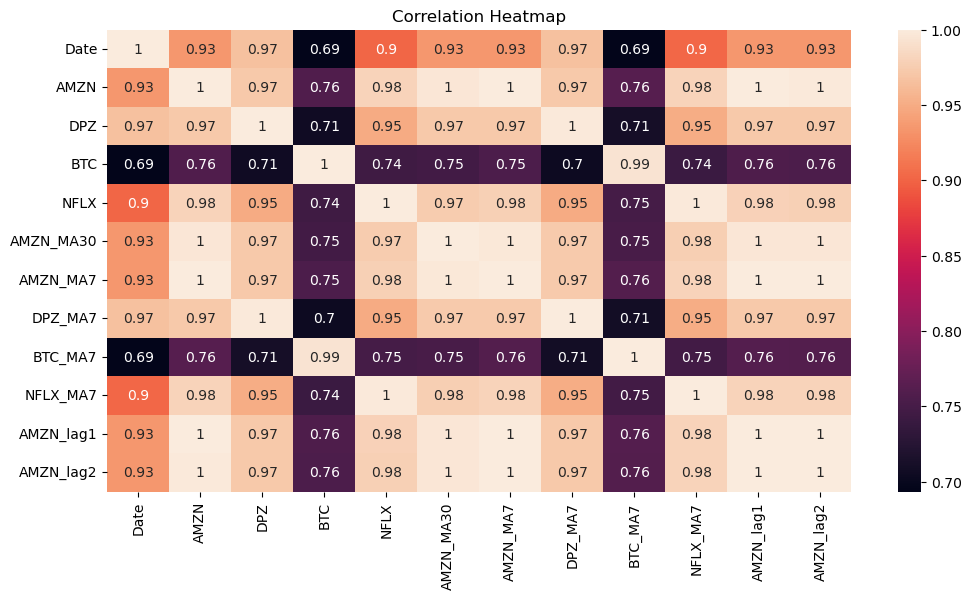

In [17]:
plt.figure(figsize=(12,6))

corr = df.corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
returns = df.drop("Date", axis=1).pct_change()

returns.std()

AMZN         0.019076
DPZ          0.015860
BTC          0.105451
NFLX         0.026756
AMZN_MA30    0.003163
AMZN_MA7     0.006876
DPZ_MA7      0.005802
BTC_MA7      0.026075
NFLX_MA7     0.010271
AMZN_lag1    0.019078
AMZN_lag2    0.019064
dtype: float64

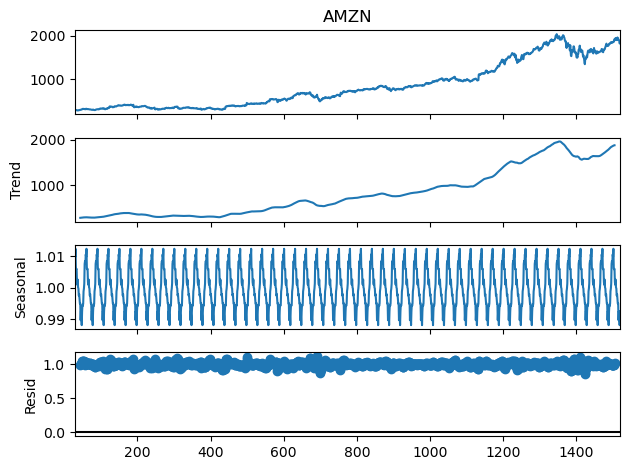

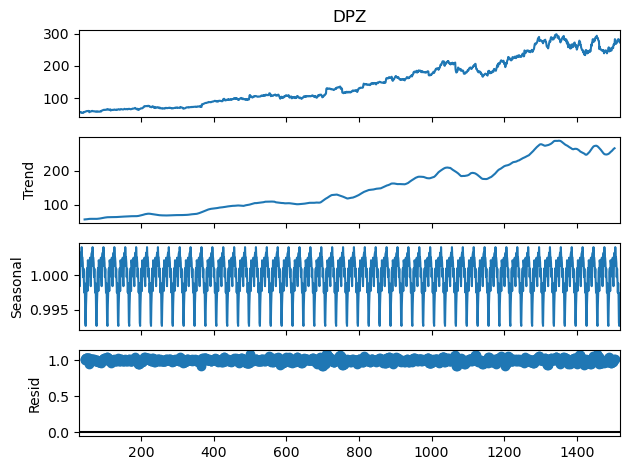

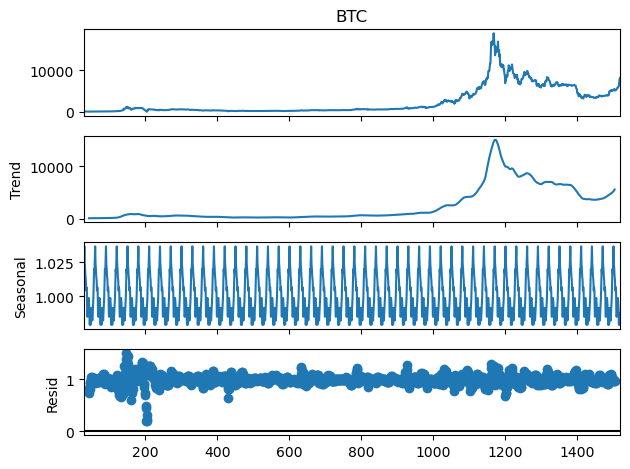

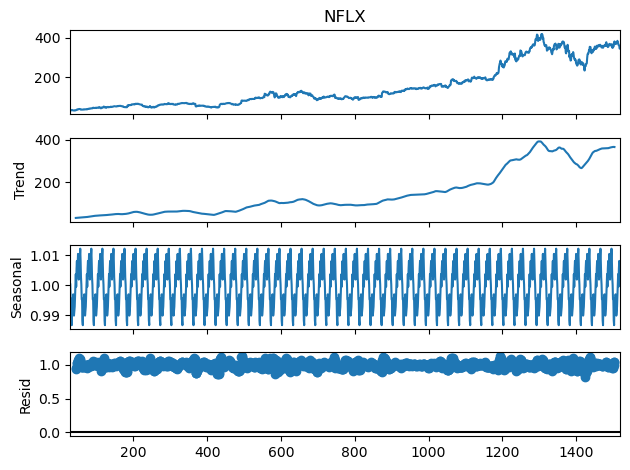

In [19]:
stocks = ['AMZN', 'DPZ', 'BTC', 'NFLX']

for stock in stocks:
    
    result = seasonal_decompose(
        df[stock],
        model='multiplicative',
        period=30
    )
    
    result.plot()

# BASELINE

# Features and Target

In [20]:
X = df[["AMZN_lag1", "AMZN_lag2", "AMZN_MA7"]]

y = df["AMZN"]

# Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [22]:
# BASELINE 1: Mean prediction
baseline_pred = [y_train.mean()] * len(y_test)

mae_base = mean_absolute_error(y_test, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline MAE:", mae_base)
print("Baseline RMSE:", rmse_base)

Baseline MAE: 1095.9586559581942
Baseline RMSE: 1106.7830342635066


# Linear Regression Model

In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [24]:
predictions = model.predict(X_test)

# Evaluation

In [25]:
mae = mean_absolute_error(y_test, predictions)

rmse = mean_squared_error(y_test, predictions) ** 0.5

print("MAE:", mae)

print("RMSE:", rmse)

MAE: 25.07555466779458
RMSE: 35.486591307918


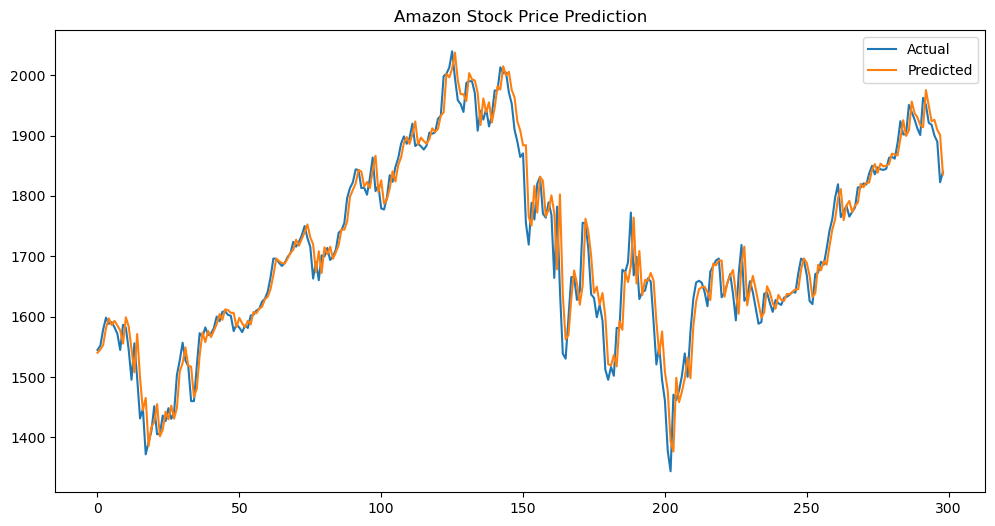

In [26]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")

plt.plot(predictions, label="Predicted")

plt.legend()

plt.title("Amazon Stock Price Prediction")

plt.show()

In [27]:
import joblib

joblib.dump(model, "amzn_model.pkl")

['amzn_model.pkl']

In [ ]:
!streamlit run app.py